In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset("iris")

print(df.head())
print(df.shape)
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


Phần 1

In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns

In [4]:
for col in numeric_cols:
    print("Column:", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Variance:", df[col].var())
    print("Std:", df[col].std())
    print("Min:", df[col].min())
    print("Max:", df[col].max())

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    print("Q1:", q1)
    print("Q3:", q3)
    print("IQR:", q3 - q1)
    print()

Column: sepal_length
Mean: 5.843333333333334
Median: 5.8
Mode: 5.0
Variance: 0.6856935123042505
Std: 0.8280661279778629
Min: 4.3
Max: 7.9
Q1: 5.1
Q3: 6.4
IQR: 1.3000000000000007

Column: sepal_width
Mean: 3.0573333333333337
Median: 3.0
Mode: 3.0
Variance: 0.1899794183445188
Std: 0.435866284936698
Min: 2.0
Max: 4.4
Q1: 2.8
Q3: 3.3
IQR: 0.5

Column: petal_length
Mean: 3.7580000000000005
Median: 4.35
Mode: 1.4
Variance: 3.1162778523489942
Std: 1.7652982332594667
Min: 1.0
Max: 6.9
Q1: 1.6
Q3: 5.1
IQR: 3.4999999999999996

Column: petal_width
Mean: 1.1993333333333336
Median: 1.3
Mode: 0.2
Variance: 0.5810062639821029
Std: 0.7622376689603465
Min: 0.1
Max: 2.5
Q1: 0.3
Q3: 1.8
IQR: 1.5



In [5]:
print(df.groupby("species").mean(numeric_only=True))

print(df.groupby("species").std(numeric_only=True))

            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026
            sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


Phần 2

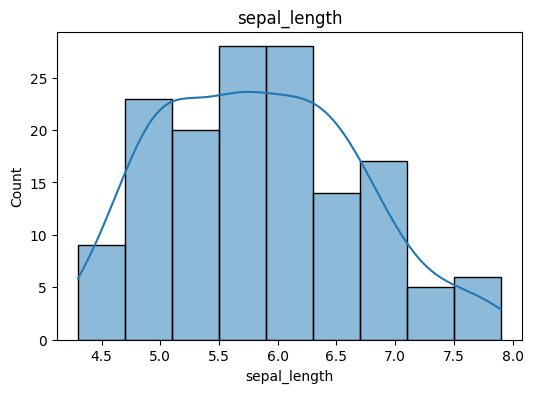

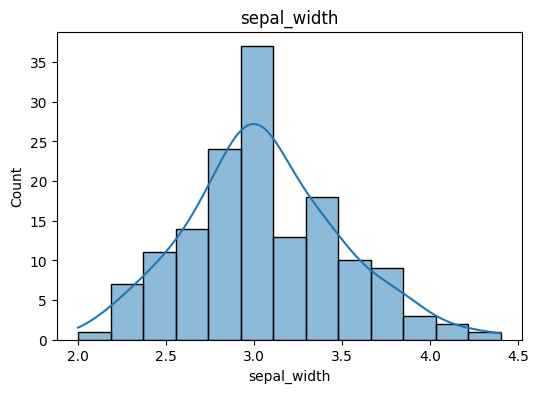

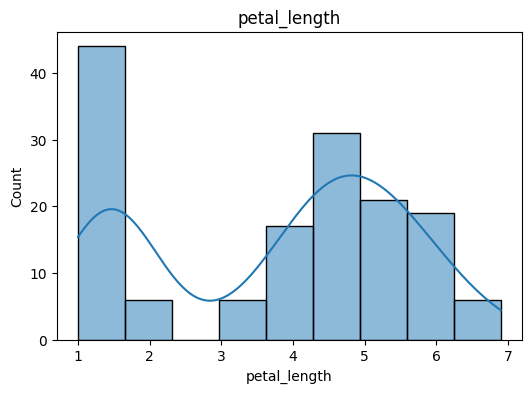

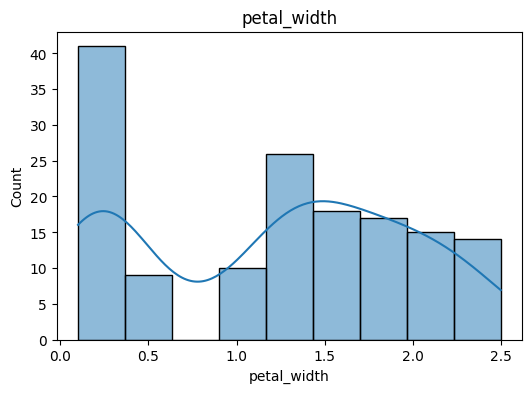

In [6]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(col)

    plt.show()

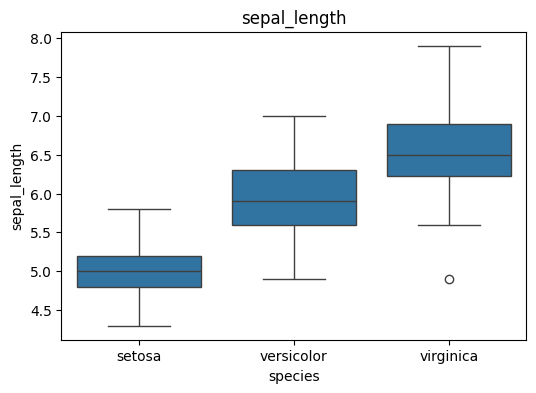

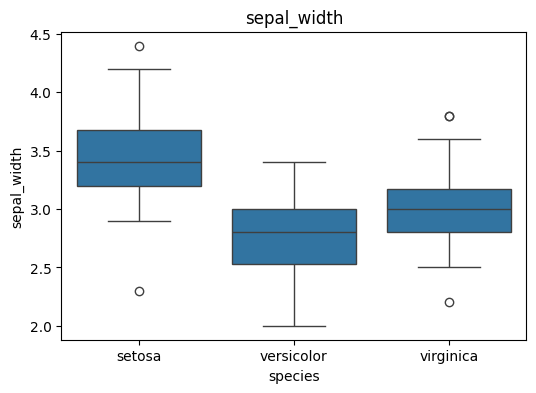

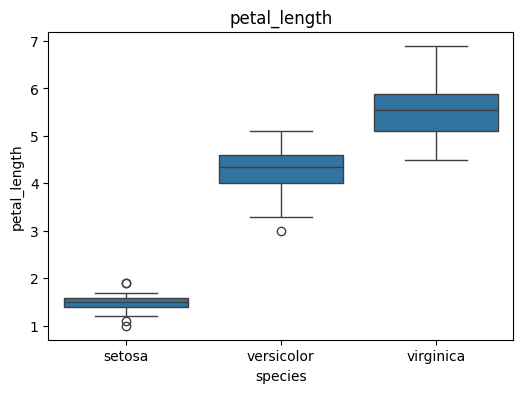

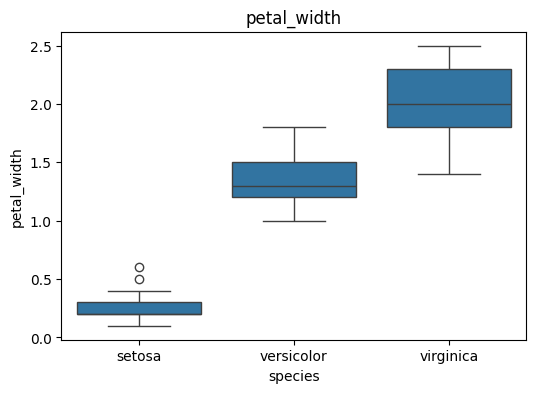

In [7]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))

    sns.boxplot(x="species", y=col, data=df)

    plt.title(col)

    plt.show()

Phần 3

In [8]:
cov_matrix = df[numeric_cols].cov()

corr_matrix = df[numeric_cols].corr()

print(cov_matrix)

print(corr_matrix)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


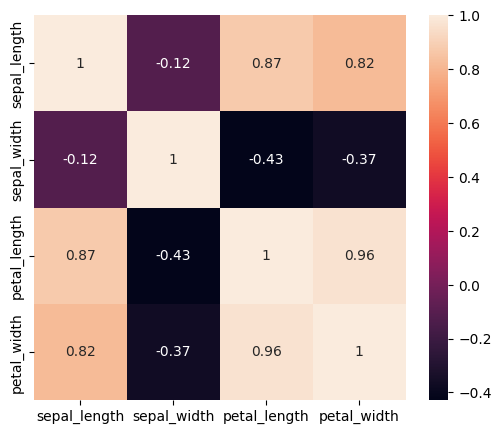

In [9]:
plt.figure(figsize=(6,5))

sns.heatmap(corr_matrix, annot=True)

plt.show()

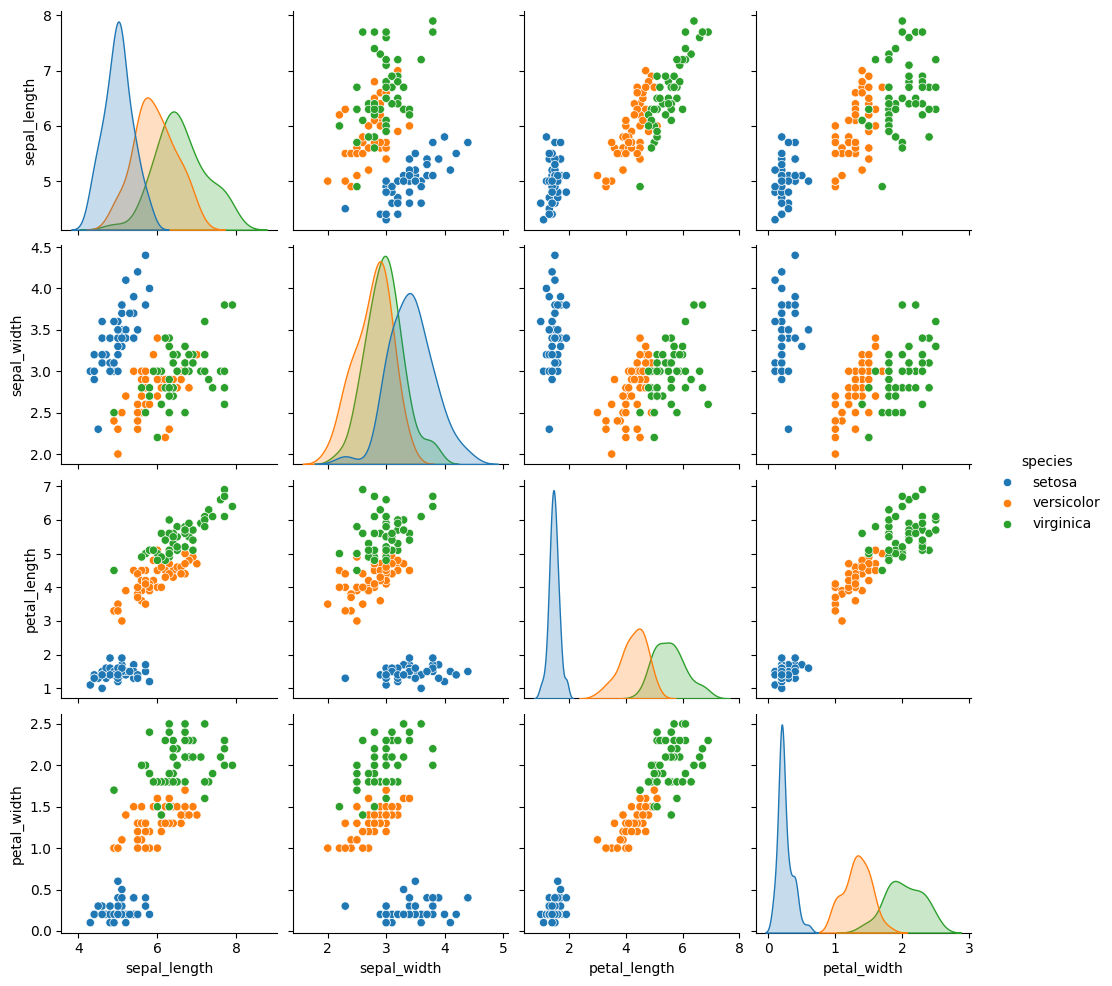

In [10]:
sns.pairplot(df, hue="species")

plt.show()

Phần 4


In [11]:
P_B = 0.01

P_pos_given_B = 0.99

P_pos_given_not_B = 0.05

P_pos = P_pos_given_B * P_B + P_pos_given_not_B * (1 - P_B)

P_B_given_pos = P_pos_given_B * P_B / P_pos

print(P_B_given_pos)

0.16666666666666669


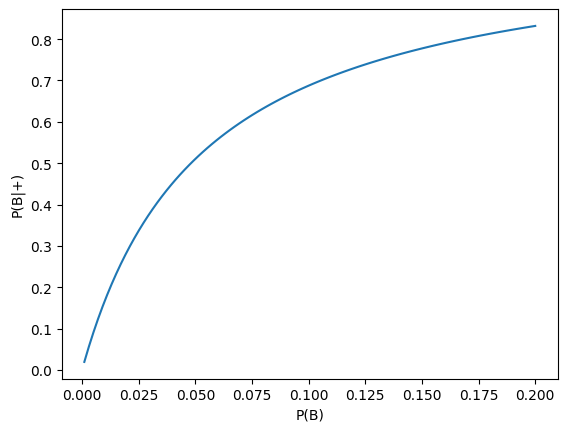

In [12]:
rates = np.linspace(0.001, 0.2, 100)

posterior = []

for p in rates:
    P_pos = P_pos_given_B * p + P_pos_given_not_B * (1 - p)
    posterior.append(P_pos_given_B * p / P_pos)

plt.plot(rates, posterior)

plt.xlabel("P(B)")

plt.ylabel("P(B|+)")

plt.show()